# Проект. Часть 3

## HR Analytics: Employee Attrition & Performance

Источник (данные не менялись): Kaggle https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/data 

Цель проекта: исследовать факторы, влияющие на текучесть кадров (Attrition) и определить, какие характеристики сотрудников повышают вероятность их ухода из компании.

### Кластеризация

Задача кластеризации — выявить типичные профили сотрудников на основе их демографических, карьерных и поведенческих характеристик, и проверить, отличаются ли полученные группы по уровню текучести (на этом этапе переменная Attrition используется только для последующей интерпретации). Это позволит понять, существуют ли группы сотрудников с разным риском ухода и какие характеристики их отличают (разведочная задача).

Использована иерархическая агломеративная кластеризация (average и ward linkage), DBSCAN и k-means не дали полезных результатов.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import decomposition

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn import metrics
from scipy.cluster.hierarchy import linkage, dendrogram

In [2]:
data = pd.read_csv("datasets/HR-Employee-Attrition.csv")
columns_to_drop = ['EducationField', 'JobRole', 'MaritalStatus', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'StockOptionLevel', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager', 'EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours', 'DailyRate', 'HourlyRate','MonthlyRate']
data = data.drop(columns=columns_to_drop)
data = pd.get_dummies(data, columns = ['Attrition', 'BusinessTravel', 'Department', 'Gender', 'OverTime'], drop_first=True)
data

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,RelationshipSatisfaction,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsSinceLastPromotion,Attrition_Yes,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,Gender_Male,OverTime_Yes
0,41,1,2,2,3,2,4,5993,1,8,0,1,0,True,False,True,False,True,False,True
1,49,8,1,3,2,2,2,5130,4,10,3,3,1,False,True,False,True,False,True,False
2,37,2,2,4,2,1,3,2090,2,7,3,3,0,True,False,True,True,False,True,True
3,33,3,4,4,3,1,3,2909,3,8,3,3,3,False,True,False,True,False,False,True
4,27,2,1,1,3,1,2,3468,4,6,3,3,2,False,False,True,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,23,2,3,4,2,4,2571,3,17,3,3,0,False,True,False,True,False,True,False
1466,39,6,1,4,2,3,1,9991,1,9,5,3,1,False,False,True,True,False,True,False
1467,27,4,3,2,4,2,2,6142,2,6,0,3,0,False,False,True,True,False,True,True
1468,49,2,3,4,2,2,2,5390,4,17,3,2,0,False,True,False,False,True,True,False


Переменные, на основе которых строятся модели кластеризации:

In [3]:
data.columns

Index(['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'RelationshipSatisfaction', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsSinceLastPromotion',
       'Attrition_Yes', 'BusinessTravel_Travel_Frequently',
       'BusinessTravel_Travel_Rarely', 'Department_Research & Development',
       'Department_Sales', 'Gender_Male', 'OverTime_Yes'],
      dtype='object')

In [4]:
data.describe()

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,RelationshipSatisfaction,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsSinceLastPromotion
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,9.192517,2.912925,2.721769,2.729932,2.063946,2.728571,6502.931293,2.712245,11.279592,2.799320,2.761224,2.187755
std,9.135373,8.106864,1.024165,1.093082,0.711561,1.106940,1.102846,4707.956783,1.081209,7.780782,1.289271,0.706476,3.222430
min,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1009.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2911.000000,2.000000,6.000000,2.000000,2.000000,0.000000
50%,36.000000,7.000000,3.000000,3.000000,3.000000,2.000000,3.000000,4919.000000,3.000000,10.000000,3.000000,3.000000,1.000000
75%,43.000000,14.000000,4.000000,4.000000,3.000000,3.000000,4.000000,8379.000000,4.000000,15.000000,3.000000,3.000000,3.000000
max,60.000000,29.000000,5.000000,4.000000,4.000000,5.000000,4.000000,19999.000000,4.000000,40.000000,6.000000,4.000000,15.000000


Нормализация:

In [5]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

Дендрограммы для разных способов измерения расстояния между кластерами:

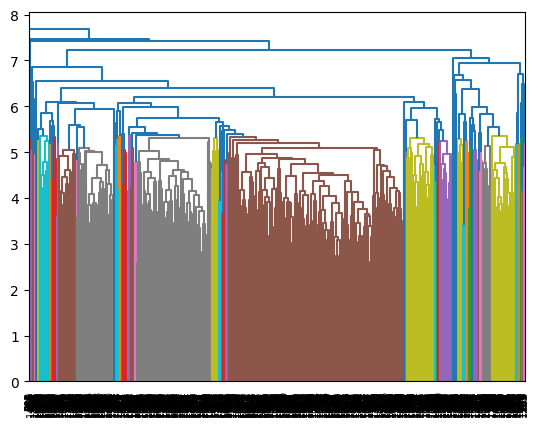

In [6]:
mergings = linkage(scaled_data, method='average')
dendrogram(mergings,
           leaf_rotation=90,
           leaf_font_size=3,
           )

plt.show()

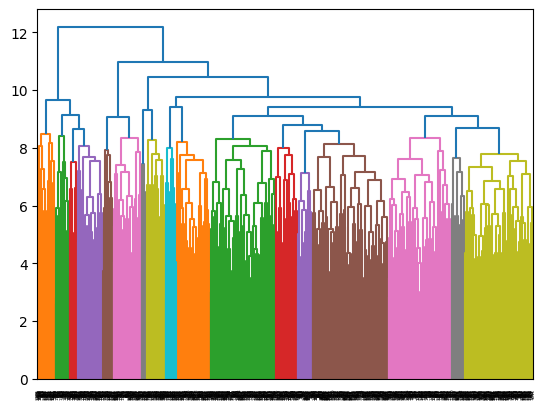

In [7]:
mergings = linkage(scaled_data, method='complete')
dendrogram(mergings,
           leaf_rotation=90,
           leaf_font_size=3,
           )

plt.show()

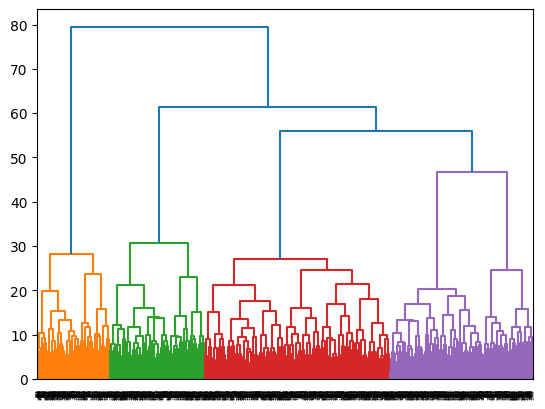

In [8]:
mergings = linkage(scaled_data, method='ward')
dendrogram(mergings,
           leaf_rotation=90,
           leaf_font_size=3,
           )

plt.show()

- average linkage даёт более сглаженную структуру

- complete linkage формирует более компактные кластеры

- ward linkage часто используется для получения интерпретируемых кластеров

На основании дендрограмм и дальнейшей интерпретации было принято решение протестировать небольшое число кластеров (2 и 4).

#### Agglomerative Clustering (Ward, 4 кластера):

In [9]:
amodel = AgglomerativeClustering(linkage = "ward", n_clusters = 4)
amodel = amodel.fit(scaled_data)
res = data.copy()
res["cluster"] = amodel.labels_
res.groupby("cluster").mean()

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,RelationshipSatisfaction,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsSinceLastPromotion,Attrition_Yes,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,Gender_Male,OverTime_Yes
cluster,,,,,,,,,,,,,,,,,,,,
0,34.507075,9.658019,2.882075,2.636792,2.646226,1.870283,2.665094,5473.061321,2.610849,8.787736,2.731132,2.771226,1.962264,0.351415,0.000000,0.882075,0.193396,0.757075,0.620283,0.370283
1,47.632558,8.809302,3.097674,2.697674,2.697674,4.093023,2.679070,15575.730233,2.809302,25.167442,2.730233,2.813953,4.851163,0.046512,0.200000,0.730233,0.720930,0.223256,0.562791,0.255814
2,34.729537,9.149466,2.893238,2.718861,2.711744,1.697509,2.822064,4809.434164,2.818505,8.861210,2.921708,2.857651,1.626335,0.249110,0.829181,0.003559,0.683274,0.274021,0.601423,0.270463
3,35.721818,9.005455,2.874545,2.798182,2.816364,1.607273,2.749091,4615.450909,2.698182,9.007273,2.816364,2.683636,1.607273,0.014545,0.001818,0.929091,0.967273,0.000000,0.598182,0.232727


Силуэт:

In [10]:
metrics.silhouette_score(scaled_data, amodel.labels_)

0.09858469961355609

**Интерпретация кластеров**

**Кластер 0**
Характеризуется:
- сравнительно молодыми сотрудниками,
- невысоким доходом и уровнем должности
- высокой долей Attrition (≈ 35%),
- частыми переработками и работой в продажах.

Это кластер повышенного риска увольнения, связанный с нагрузкой и низкой стабильностью.

**Кластер 1**
Старшие сотрудники с:
- высоким доходом,
- большим стажем,
- высокой должностью,
- минимальной текучестью (≈ 4.6%).

Это стабильный кластер, менее склонный к увольнениям.

**Кластеры 2 и 3**
Промежуточные группы с:
- умеренным доходом,
- средним уровнем удовлетворённости,
- низкой или умеренной текучестью.
Кластеризация выявляет осмысленные профили сотрудников, различающиеся по уровню Attrition, однако разделение на 4 кластера даёт относительно слабое разделение по метрике качества. Тем не менее, даже при низком silhouette score кластеры могут быть интерпретированы.

#### Agglomerative Clustering (Average, 2 кластера):

In [11]:
bmodel = AgglomerativeClustering(linkage = "average", n_clusters = 2)
bmodel = bmodel.fit(scaled_data)
bres = data.copy()
bres["cluster"] = bmodel.labels_
bres.groupby('cluster').mean()

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,RelationshipSatisfaction,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsSinceLastPromotion,Attrition_Yes,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,Gender_Male,OverTime_Yes
cluster,,,,,,,,,,,,,,,,,,,,
0,36.939373,9.168937,2.91485,2.722071,2.732289,2.064714,2.728883,6507.644414,2.71049,11.28951,2.796322,2.760899,2.188692,0.160082,0.188011,0.71049,0.654632,0.302452,0.599455,0.282698
1,25.500000,26.500000,1.50000,2.500000,1.000000,1.500000,2.500000,3043.500000,4.00000,4.00000,5.000000,3.000000,1.500000,1.000000,0.500000,0.00000,0.000000,1.000000,1.000000,0.500000


Силуэт: Значение выше, чем для 4 кластеров, что говорит о более устойчивом и интерпретируемом разбиении.

In [12]:
metrics.silhouette_score(scaled_data, bmodel.labels_)

0.182765367316027

**Интерпретация кластеров**

**Кластер 0** (основная масса сотрудников)
- средний возраст и доход,
- умеренная удовлетворённость,
- Attrition ≈ 16%.
**Кластер 1** (малый кластер)
- очень молодые сотрудники,
- крайне низкий доход,
- высокий уровень Attrition (100%).
Этот кластер представляет собой крайний профиль риска.

#### Agglomerative Clustering (Average, 2 кластера, сокращённый набор признаков):

Уменьшим количество переменных:

In [16]:
small_data = data.copy()
col_drop = ['TotalWorkingYears', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales']
small_data = small_data.drop(columns=col_drop)
small_data

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,RelationshipSatisfaction,TrainingTimesLastYear,WorkLifeBalance,YearsSinceLastPromotion,Attrition_Yes,Gender_Male,OverTime_Yes
0,41,1,2,2,3,2,4,5993,1,0,1,0,True,False,True
1,49,8,1,3,2,2,2,5130,4,3,3,1,False,True,False
2,37,2,2,4,2,1,3,2090,2,3,3,0,True,True,True
3,33,3,4,4,3,1,3,2909,3,3,3,3,False,False,True
4,27,2,1,1,3,1,2,3468,4,3,3,2,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,23,2,3,4,2,4,2571,3,3,3,0,False,True,False
1466,39,6,1,4,2,3,1,9991,1,5,3,1,False,True,False
1467,27,4,3,2,4,2,2,6142,2,0,3,0,False,True,True
1468,49,2,3,4,2,2,2,5390,4,3,2,0,False,True,False


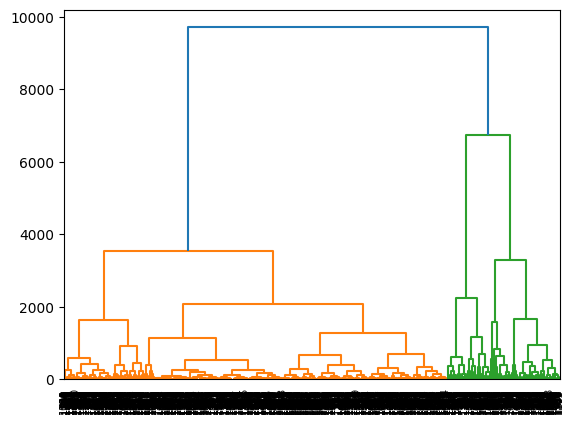

In [17]:
scaler = StandardScaler()
scaled_small = scaler.fit_transform(small_data)

mergings = linkage(small_data, method='average')
dendrogram(mergings,
           leaf_rotation=90,
           leaf_font_size=7,
           )

plt.show()

In [18]:
s_amodel = AgglomerativeClustering(linkage = "average", n_clusters = 2)
s_amodel = s_amodel.fit(scaled_small)
res = small_data.copy()
res["cluster"] = s_amodel.labels_
res.groupby("cluster").mean()

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,RelationshipSatisfaction,TrainingTimesLastYear,WorkLifeBalance,YearsSinceLastPromotion,Attrition_Yes,Gender_Male,OverTime_Yes
cluster,,,,,,,,,,,,,,,
0,36.811813,9.181319,2.906593,2.724588,2.732143,2.047390,2.732830,6435.009615,2.708104,2.808379,2.767170,2.127747,0.153159,0.598901,0.279533
1,48.571429,10.357143,3.571429,2.428571,2.500000,3.785714,2.285714,13566.785714,3.142857,1.857143,2.142857,8.428571,1.000000,0.714286,0.642857


Силуэт:

Это наилучшее значение silhouette score среди протестированных вариантов. Оно подтверждает, что снижение размерности признаков улучшает качество кластеризации.

In [19]:
metrics.silhouette_score(scaled_small, s_amodel.labels_)

0.20823714444052516

**Интерпретация кластеров**

После сокращения числа переменных кластеры становятся более различимыми, но их характеристики поменялись:

**Кластер 0** — большинство сотрудников, умеренный риск ухода (≈ 15%).

**Кластер 1** — небольшая группа с:
- высоким доходом,
- высоким уровнем должности,
- большим временем без повышения,
- Attrition = 100%.
Это указывает на возможный эффект карьерного плато: даже высокооплачиваемые сотрудники могут уходить при отсутствии карьерного роста.

Adjusted Rand Index:

In [20]:
segments = pd.cut(small_data["YearsSinceLastPromotion"], bins = 4, right = False)
segments

0       [0.0, 3.75)
1       [0.0, 3.75)
2       [0.0, 3.75)
3       [0.0, 3.75)
4       [0.0, 3.75)
           ...     
1465    [0.0, 3.75)
1466    [0.0, 3.75)
1467    [0.0, 3.75)
1468    [0.0, 3.75)
1469    [0.0, 3.75)
Name: YearsSinceLastPromotion, Length: 1470, dtype: category
Categories (4, interval[float64, left]): [[0.0, 3.75) < [3.75, 7.5) < [7.5, 11.25) < [11.25, 15.015)]

Низкое значение ARI (0.038) показывает, что кластеры почти не совпадают с разбиением по времени с последнего повышения. Это означает, что кластеризация выявляет новую структуру, а не воспроизводит один из признаков.

In [21]:
metrics.adjusted_rand_score(s_amodel.labels_, segments)

0.03781512687475279

#### DBSCAN

Алгоритм DBSCAN не дал каких-либо интерпретируемых результатов: большинство наблюдений попадает в шум (-1), а те группы, которые выделяются, не интересны с точки зрения Attrition (+ небольшие кластеры плохо обобщаемы).

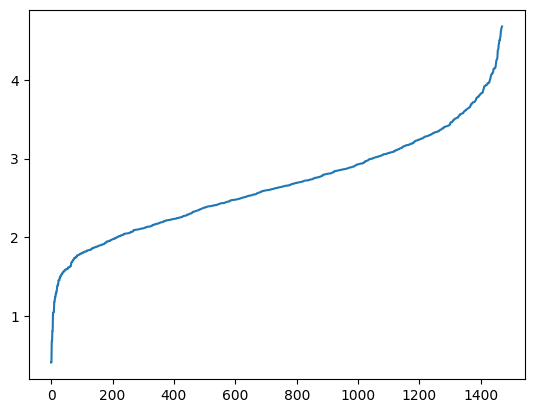

In [13]:
from sklearn.neighbors import NearestNeighbors
neigh = NearestNeighbors(n_neighbors=2)
nbrs = neigh.fit(scaled_data)
distances, indices = nbrs.kneighbors(scaled_data)
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.plot(distances)

In [14]:
from sklearn.cluster import DBSCAN
dbmodel = DBSCAN(eps=3, min_samples=20)
dbmodel = dbmodel.fit(scaled_data)
dbpred = dbmodel.labels_

res = data.copy()
res["cluster"] = dbmodel.labels_
res.groupby("cluster").mean()

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,RelationshipSatisfaction,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsSinceLastPromotion,Attrition_Yes,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,Gender_Male,OverTime_Yes
cluster,,,,,,,,,,,,,,,,,,,,
-1,38.022908,9.730080,2.866534,2.674303,2.678287,2.256972,2.721116,7318.243028,2.711155,12.534861,2.806773,2.721116,2.635458,0.236056,0.275896,0.591633,0.595618,0.349602,0.575697,0.375498
0,34.572973,7.891892,2.956757,2.797297,2.848649,1.554054,2.727027,4442.297297,2.743243,8.524324,2.759459,2.837838,1.202703,0.000000,0.000000,0.956757,0.981081,0.000000,0.640541,0.100000
1,34.489583,8.583333,3.229167,2.927083,2.812500,2.010417,2.812500,5918.156250,2.604167,8.770833,2.875000,2.885417,1.302083,0.000000,0.000000,0.989583,0.000000,0.989583,0.697917,0.020833


Шум: 1004 наблюдения из 1470

In [15]:
res.groupby("cluster").size()

cluster
-1    1004
 0     370
 1      96
dtype: int64

#### Основные выводы

- В данных нет чётких сегментов, но выделяются устойчивые профили сотрудников.
- Наиболее интерпретируемым оказалось разбиение на 2 кластера, отражающее группу повышенного риска ухода.
- Кластеры существенно различаются по Attrition, но метрики не очень высокие.

#### Полезность для основной задачи

Кластеризация дополняет регрессионный анализ, позволяет перейти от отдельных факторов к типам сотрудников, помогает выявить группы риска и возможные сценарии ухода.

При этом метод носит описательный характер и не предназначен для точного прогнозирования, но может помочь в принятии управленческих решений.

### Subgroup Discovery

Задача Subgroup Discovery — выявить интерпретируемые подгруппы сотрудников, которые уволились из компании, и описать эти подгруппы в виде правил (сочетаний характеристик). В отличие от кластеризации, здесь Attrition напрямую используется как целевая переменная.

Для выделения подгрупп был применена библиотека pysubgroup. В качестве целевой переменной задан бинарный индикатор увольнения (Attrition_Yes = 1). Поиск подгрупп осуществлялся методом лучевого поиска, который итеративно расширяет наиболее перспективные правила, ограничивая их глубину (до 5 условий). В качестве функции качества использовался хи-квадрат, что позволяет выявлять подгруппы, в которых доля уволившихся сотрудников статистически значимо отличается от средней по выборке. Этот подход поможет обнаружить локальные закономерности, характерные для отдельных сегментов сотрудников.

In [22]:
!pip install pysubgroup


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [29]:
import pysubgroup as ps
task = ps.SubgroupDiscoveryTask (
    data,
    ps.BinaryTarget("Attrition_Yes", target_value=1),
    ps.create_selectors(data, ignore=['Attrition_Yes']),
    result_set_size=10,
    depth=5,
    qf=ps.ChiSquaredQF()
)
ps.BeamSearch().execute(task).to_dataframe()

,quality,subgroup,size_sg,size_dataset,positives_sg,positives_dataset,size_complement,relative_size_sg,relative_size_complement,coverage_sg,coverage_complement,target_share_sg,target_share_complement,target_share_dataset,lift
0,171.382299,JobLevel==1 AND OverTime_Yes==True,156,1470,82,237,1314,0.106122,0.893878,0.345992,0.654008,0.525641,0.117960,0.161224,3.260305
1,149.931884,JobLevel==1 AND MonthlyIncome<2696 AND OverTim...,85,1470,54,237,1385,0.057823,0.942177,0.227848,0.772152,0.635294,0.132130,0.161224,3.940432
2,141.671731,MonthlyIncome<2696 AND OverTime_Yes==True,88,1470,54,237,1382,0.059864,0.940136,0.227848,0.772152,0.613636,0.132417,0.161224,3.806099
3,119.678301,Department_Sales==False AND JobLevel==1 AND Ov...,134,1470,66,237,1336,0.091156,0.908844,0.278481,0.721519,0.492537,0.127994,0.161224,3.054978
4,115.970676,JobLevel==1 AND OverTime_Yes==True AND YearsSi...,71,1470,44,237,1399,0.048299,0.951701,0.185654,0.814346,0.619718,0.137956,0.161224,3.843822
5,112.355815,JobLevel==1 AND MonthlyIncome<2696 AND OverTim...,45,1470,33,237,1425,0.030612,0.969388,0.139241,0.860759,0.733333,0.143158,0.161224,4.548523
6,111.543756,Department_Research & Development==True AND Jo...,126,1470,62,237,1344,0.085714,0.914286,0.261603,0.738397,0.492063,0.130208,0.161224,3.052039
7,111.543756,Department_Research & Development==True AND De...,126,1470,62,237,1344,0.085714,0.914286,0.261603,0.738397,0.492063,0.130208,0.161224,3.052039
8,111.106108,JobLevel==1 AND MonthlyIncome<2696 AND OverTim...,50,1470,35,237,1420,0.034014,0.965986,0.147679,0.852321,0.700000,0.142254,0.161224,4.341772
9,109.833722,Department_Sales==False AND JobLevel==1 AND Mo...,68,1470,42,237,1402,0.046259,0.953741,0.177215,0.822785,0.617647,0.139087,0.161224,3.830975


#### Интерпретация полученных правил

Общая доля увольнений в датасете составляет около 16%. Все выявленные подгруппы характеризуются существенно более высокой долей Attrition и высоким значением lift (от 3 до 4.5), что указывает на сильное отклонение от среднего уровня текучести.

- **JobLevel = 1 AND OverTime = Yes:** Доля увольнений в подгруппе: 52.6%. Сотрудники начального уровня, работающие сверхурочно, увольняются значительно чаще, чем в среднем по компании.
- **JobLevel = 1 AND MonthlyIncome < 2696 AND OverTime = Yes:** Доля увольнений: 63–64%. Добавление низкого дохода существенно усиливает эффект: сочетание начального уровня должности, сверхурочной работы и низкой зарплаты формирует крайне уязвимую подгруппу.
- **JobLevel = 1 AND OverTime = Yes AND YearsSinceLastPromotion: [0;1):** Доля увольнений: 62%. Недавнее повышение не компенсирует негативный эффект перегрузки и низкого уровня должности.
- **Department_Research & Development = True AND JobLevel = 1 AND OverTime = Yes:** Доля увольнений: 49.2%. Сотрудники отдела R&D с низким уровнем должности и переработками особенно склонны к увольнениям. (В группе достаточно много человек — 126.)
- **JobLevel = 1 AND MonthlyIncome < 2696 AND OverTime = Yes AND WorkLifeBalance = 3:** Доля увольнений: 70%. Даже относительно нормальный уровень WorkLifeBalance не снижает риск ухода, если присутствуют переработки, низкий доход и начальный уровень должности. Это подчёркивает доминирующую роль нагрузки и оплаты труда.
Все группы получились достаточно большими.

In [35]:
import pysubgroup as ps
task2 = ps.SubgroupDiscoveryTask (
    small_data,
    ps.BinaryTarget("Attrition_Yes", target_value=1),
    ps.create_selectors(small_data, ignore=['Attrition_Yes']),
    result_set_size=10,
    depth=3,
    qf=ps.ChiSquaredQF()
)
ps.BeamSearch().execute(task2).to_dataframe()

,quality,subgroup,size_sg,size_dataset,positives_sg,positives_dataset,size_complement,relative_size_sg,relative_size_complement,coverage_sg,coverage_complement,target_share_sg,target_share_complement,target_share_dataset,lift
0,171.382299,JobLevel==1 AND OverTime_Yes==True,156,1470,82,237,1314,0.106122,0.893878,0.345992,0.654008,0.525641,0.117960,0.161224,3.260305
1,149.931884,JobLevel==1 AND MonthlyIncome<2696 AND OverTim...,85,1470,54,237,1385,0.057823,0.942177,0.227848,0.772152,0.635294,0.132130,0.161224,3.940432
2,141.671731,MonthlyIncome<2696 AND OverTime_Yes==True,88,1470,54,237,1382,0.059864,0.940136,0.227848,0.772152,0.613636,0.132417,0.161224,3.806099
3,115.970676,JobLevel==1 AND OverTime_Yes==True AND YearsSi...,71,1470,44,237,1399,0.048299,0.951701,0.185654,0.814346,0.619718,0.137956,0.161224,3.843822
4,105.044324,MonthlyIncome<2696 AND OverTime_Yes==True AND ...,47,1470,33,237,1423,0.031973,0.968027,0.139241,0.860759,0.702128,0.143359,0.161224,4.354969
5,104.437686,MonthlyIncome<2696 AND OverTime_Yes==True AND ...,52,1470,35,237,1418,0.035374,0.964626,0.147679,0.852321,0.673077,0.142454,0.161224,4.174781
6,102.187524,JobLevel==1 AND OverTime_Yes==True AND WorkLif...,88,1470,48,237,1382,0.059864,0.940136,0.202532,0.797468,0.545455,0.136758,0.161224,3.383199
7,99.864480,Age<29 AND JobLevel==1 AND OverTime_Yes==True,56,1470,36,237,1414,0.038095,0.961905,0.151899,0.848101,0.642857,0.142150,0.161224,3.987342
8,96.368605,Gender_Male==True AND JobLevel==1 AND OverTime...,97,1470,50,237,1373,0.065986,0.934014,0.210970,0.789030,0.515464,0.136198,0.161224,3.197181
9,93.787411,Gender_Male==True AND MonthlyIncome<2696 AND O...,53,1470,34,237,1417,0.036054,0.963946,0.143460,0.856540,0.641509,0.143260,0.161224,3.978983


Выделение подгрупп на меньшем количестве характеристик наблюдений с меньшей глубиной правил выявляет дополнительные правила, связанные с полом и возрастом (но возраст умеренно коррелирует с уровнем должности JobLevel):
- **Gender = Male AND JobLevel = 1 AND OverTime = Yes:** Доля увольнений: 51.6%
- **Gender = Male AND MonthlyIncome < 2696 AND OverTime = Yes:** Доля увольнений: 64.2%
- **Age < 29 AND JobLevel = 1 AND OverTime = Yes:** Доля увольнений: 64.3%

#### Основные выводы

Subgroup Discovery показывает, что увольнение сотрудников редко связано с одним фактором. Наибольший риск возникает при сочетании нескольких условий:
- начальный уровень должности
- переработки
- низкий доход
- ограниченные карьерные перспективы
Выявленные правила подтверждают и уточняют результаты регрессионного анализа, показывая не только направление влияния факторов, но и более полные сценарии, при которых вероятность ухода становится действительно высокой.

#### Полезность для основной задачи

Метод Subgroup Discovery позволяет выявлять подгруппы риска, за которыми стоит наблюдать. Правила легко интерпретируются и могут быть использованы в коммуникации с HR и менеджментом. Результаты могут помочь разработать меры, направленные на удержание сотрудников.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=ff5c65e0-9edf-47b2-8d5a-439e7f5c1ece' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>